## Problem Statement 1
# `walmart Sales Forecasting`

# Project Objective

The objective of this analysis is to study the historical sales data of Walmart stores and identify patterns affecting sales performance. Using these insights, a predictive model is built to forecast store sales for the upcoming 12 weeks.

Accurate forecasting allows retail managers to align supply with expected demand and improve inventory efficiency.

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

# Phase 1 — Load and Prepare the Data

In [2]:
df = pd.read_csv(r"C:\Users\adity\Downloads\Inteelipat course\Walmart (1).csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [4]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values('Date')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 452.5 KB


In [5]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week

In [6]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 6435 entries, 0 to 6434
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
 8   Year          6435 non-null   int32         
 9   Month         6435 non-null   int32         
 10  Week          6435 non-null   UInt32        
dtypes: UInt32(1), datetime64[ns](1), float64(5), int32(2), int64(2)
memory usage: 534.2 KB


Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
Year            0
Month           0
Week            0
dtype: int64

# Phase 2 — Exploratory Insights (Very Important for the Report)

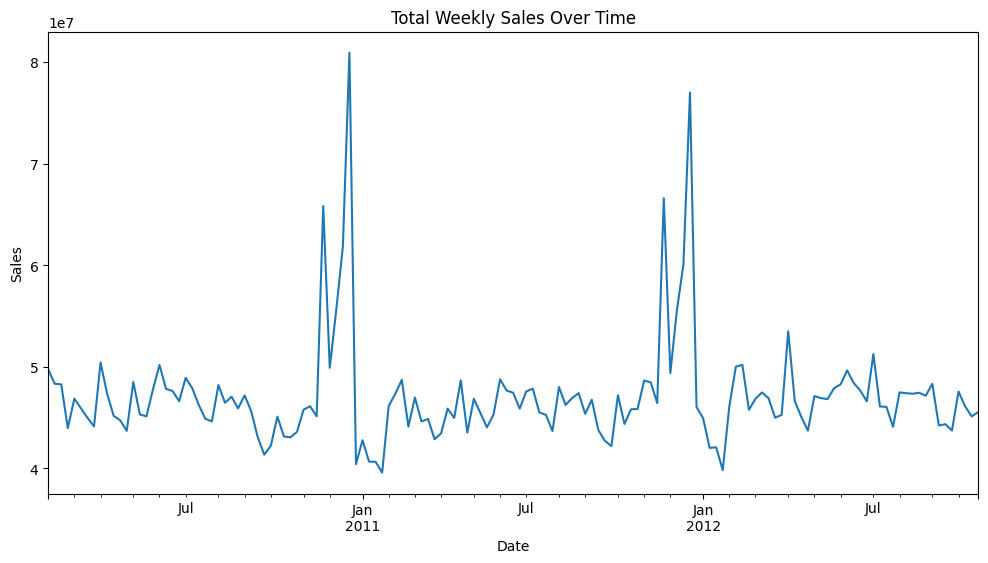

In [8]:
plt.figure(figsize=(12,6))
df.groupby('Date')['Weekly_Sales'].sum().plot()
plt.title("Total Weekly Sales Over Time")
plt.ylabel("Sales")
plt.show()

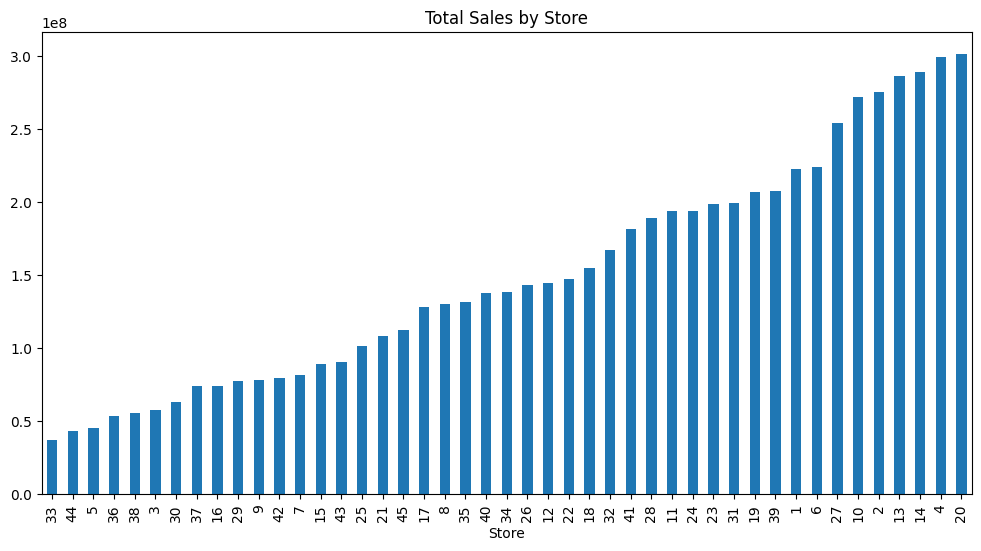

In [9]:
store_sales = df.groupby('Store')['Weekly_Sales'].sum().sort_values()

store_sales.plot(kind='bar', figsize=(12,6))
plt.title("Total Sales by Store")
plt.show()

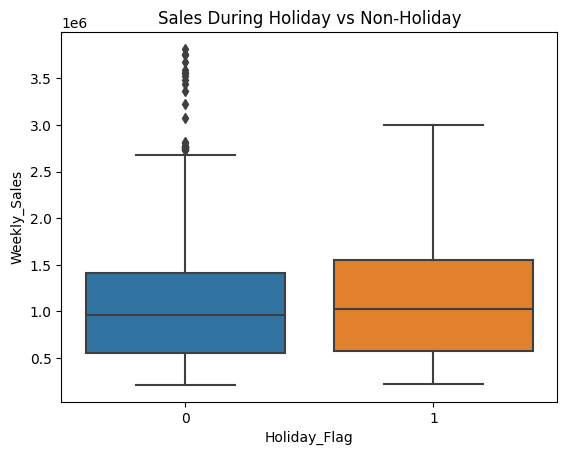

In [10]:
sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=df)
plt.title("Sales During Holiday vs Non-Holiday")
plt.show()

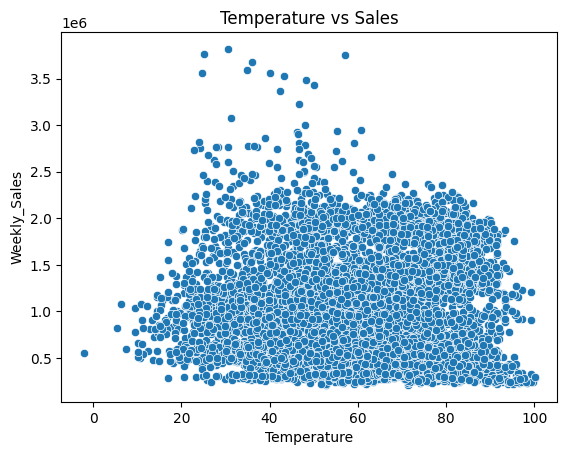

In [11]:
sns.scatterplot(x='Temperature', y='Weekly_Sales', data=df)
plt.title("Temperature vs Sales")
plt.show()

# Phase 3 — Forecasting Sales

In [13]:
store1 = df[df['Store']==1]
store1 = store1.set_index('Date')

<Axes: xlabel='Date'>

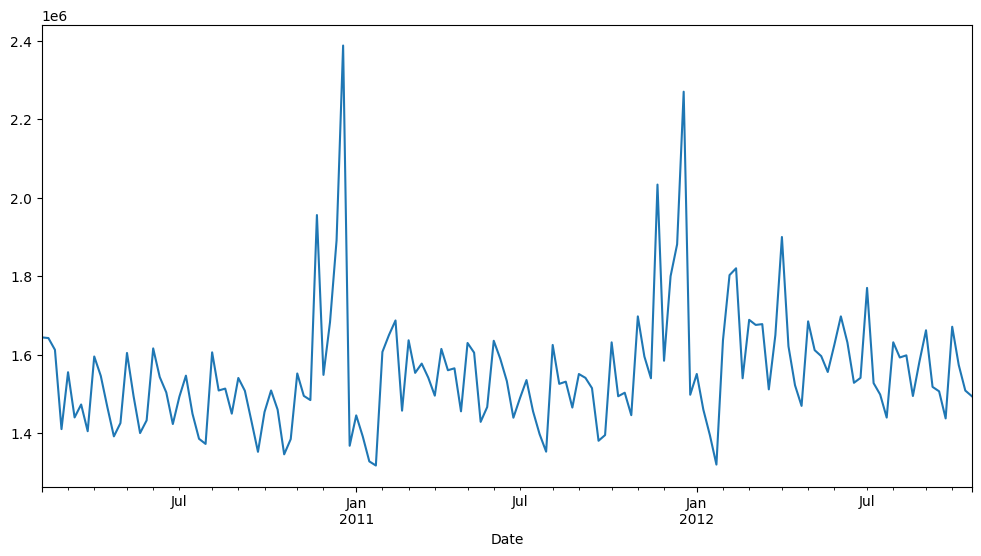

In [14]:
store1['Weekly_Sales'].plot(figsize=(12,6))

In [15]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(store1['Weekly_Sales'], order=(2,1,2))
model_fit = model.fit()

C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


In [16]:
forecast = model_fit.forecast(steps=12)
print(forecast)

2012-11-02    1.541700e+06
2012-11-09    1.549739e+06
2012-11-16    1.565859e+06
2012-11-23    1.562411e+06
2012-11-30    1.570376e+06
2012-12-07    1.565666e+06
2012-12-14    1.570852e+06
2012-12-21    1.566786e+06
2012-12-28    1.570579e+06
2013-01-04    1.567354e+06
2013-01-11    1.570232e+06
2013-01-18    1.567728e+06
Freq: W-FRI, Name: predicted_mean, dtype: float64


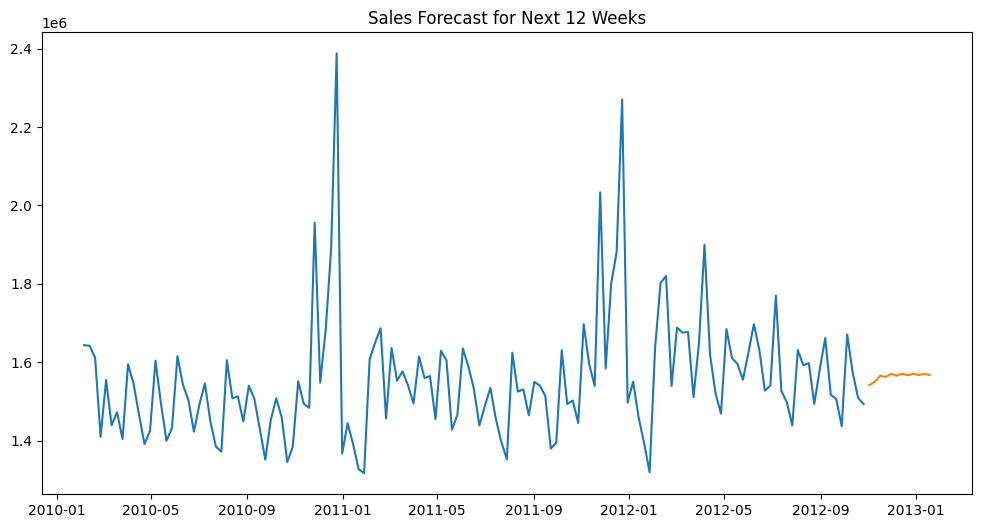

In [17]:
plt.figure(figsize=(12,6))
plt.plot(store1['Weekly_Sales'])
plt.plot(forecast)
plt.title("Sales Forecast for Next 12 Weeks")
plt.show()

# Phase 4 — Model Evaluation

In [18]:
from sklearn.metrics import mean_squared_error
pred = model_fit.predict()
rmse = np.sqrt(mean_squared_error(store1['Weekly_Sales'][1:], pred[1:]))
print("RMSE:", rmse)

RMSE: 161691.04355350032


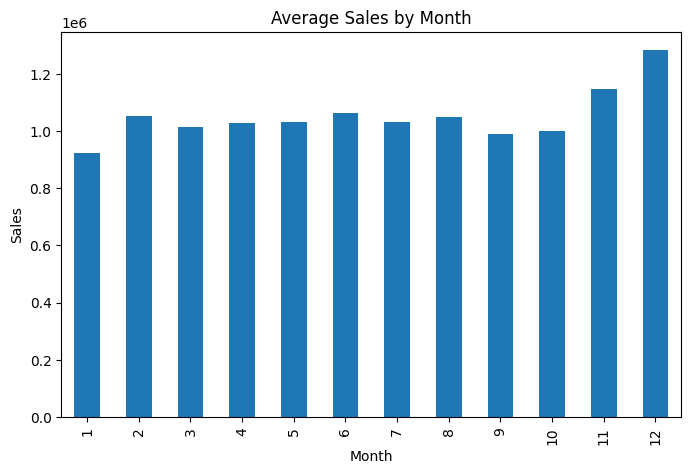

In [20]:
monthly_sales = df.groupby('Month')['Weekly_Sales'].mean()
monthly_sales.plot(kind='bar', figsize=(8,5))
plt.title("Average Sales by Month")
plt.ylabel("Sales")
plt.show()